Usamos el script "segmentacion.py" para procesar dos frames distintos (0050 y 0100) y generar las imágenes de evidencia.

Cargando modelo Baseline...
Segmentando frame_0050.jpg...
Ultralytics 8.4.57  Python-3.11.15 torch-2.12.0+cpu CPU (AMD Ryzen 5 5625U with Radeon Graphics)
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]
Results saved to C:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora\notebooks\runs\segment\predict-10
Imagen guardada en: ../docs/assets/m1/baseline\baseline_frame_0050.jpg
Segmentando frame_0100.jpg...
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]
Results saved to C:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora\notebooks\runs\segment\predict-10
Imagen guardada en: ../docs/assets/m1/baseline\baseline_frame_0100.jpg


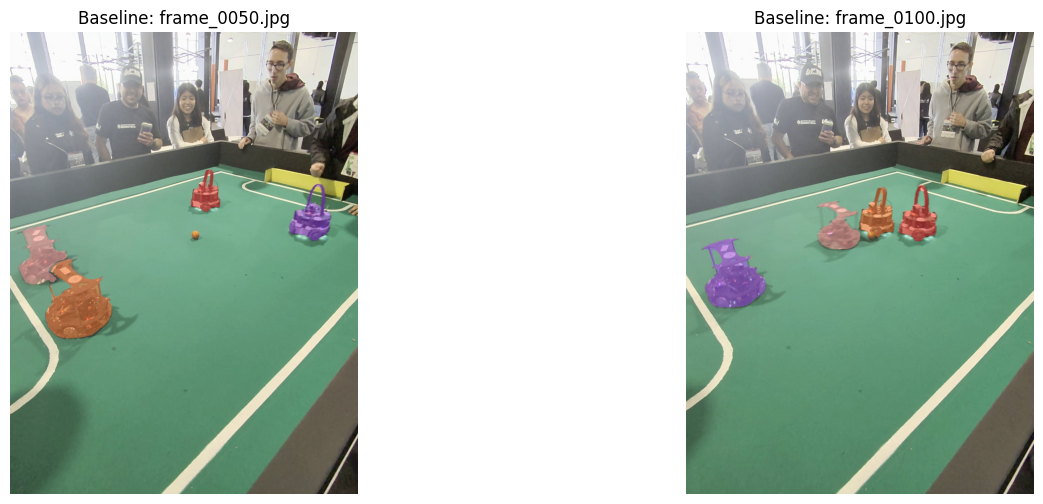


Procesamiento Baseline completado


In [4]:
import sys
import os
import cv2
import matplotlib.pyplot as plt
import supervision as sv

# 1. Importar configuraciones y nuestro nuevo módulo local
sys.path.append(os.path.abspath("../src"))
from config import MODEL_PATH
from segmentation import load_text_prompt_predictor, segment_with_text_prompt

# 2. Preparar el directorio de salida
out_dir = "../docs/assets/m1/baseline"
os.makedirs(out_dir, exist_ok=True)

# 3. Cargar el modelo a través de nuestra función
print("Cargando modelo Baseline...")
predictor = load_text_prompt_predictor(MODEL_PATH)
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)

# 4. Definir los frames a procesar (como pide el Issue)
frames_a_probar = ["frame_0050.jpg", "frame_0100.jpg"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 5. Ejecutar pipeline
for i, nombre_frame in enumerate(frames_a_probar):
    print(f"Segmentando {nombre_frame}...")
    img_path = f"../docs/assets/m1/frames/{nombre_frame}"
    image = cv2.imread(img_path)
    
    if image is None:
        print(f"Error: No se encontró {img_path}")
        continue
    
    # Aplicar la función reutilizable
    detections = segment_with_text_prompt(predictor, image, "robot")
    
    # Dibujar la máscara
    annotated = mask_annotator.annotate(scene=image.copy(), detections=detections)
    
    # Guardar la imagen en disco
    out_file = os.path.join(out_dir, f"baseline_{nombre_frame}")
    cv2.imwrite(out_file, annotated)
    print(f"Imagen guardada en: {out_file}")
    
    # Visualizar en el notebook
    axes[i].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Baseline: {nombre_frame}")
    axes[i].axis("off")

plt.show()
print("\nProcesamiento Baseline completado")